# Lecture 5 — Class Exercise
## Distribution Charts: Airbnb London

In [1]:
import pandas as pd
import plotly.express as px
import numpy as np

# Dataset: Airbnb London Listings

df = pd.read_csv('../data/airbnb_london.csv')
print(f"Loaded: {len(df)} listings")
print(df.describe().round(1))


Loaded: 2500 listings
        price  minimum_nights  number_of_reviews  availability_365  \
count  2500.0          2500.0             2500.0            2500.0   
mean    148.6            14.8              147.9             183.7   
std     110.9             8.4               86.3             105.5   
min      20.5             1.0                0.0               0.0   
25%      71.7             8.0               74.0              92.0   
50%     117.5            15.0              145.0             182.0   
75%     188.9            22.0              222.2             277.0   
max    1032.4            29.0              299.0             364.0   

       reviews_per_month  
count             2500.0  
mean                 2.0  
std                  2.0  
min                  0.0  
25%                  0.6  
50%                  1.4  
75%                  2.8  
max                 15.2  


In [2]:
p95 = df['price'].quantile(0.95)
df_cap = df[df['price'] <= p95]
print(f"95th percentile price: £{p95:.0f}")
print(df_cap.groupby('room_type')['price'].describe().round(1))


95th percentile price: £373
                  count   mean   std   min    25%    50%    75%    max
room_type                                                             
Entire home/apt  1251.0  176.3  75.7  28.0  119.6  163.4  223.5  372.6
Private room      942.0   87.3  39.5  20.9   59.0   78.6  106.0  277.9
Shared room       182.0   46.3  14.1  20.5   36.8   44.1   54.3   92.8


## Task 1 — Histogram: price by room type (overlapping distributions)

**What to build:** A histogram showing price distributions for **Entire home/apt vs Private room** (exclude Shared room — too few observations) overlaid on the same chart.

**Requirements:**
- Both room types on the same chart (use `color='room_type'`)
- `barmode='overlay'` with `opacity=0.6` so both distributions are visible
- A vertical line for the median of EACH room type, differently coloured
- Insight title comparing the two distributions

> 💡 `df_cap[df_cap['room_type'].isin(['Entire home/apt','Private room'])]`


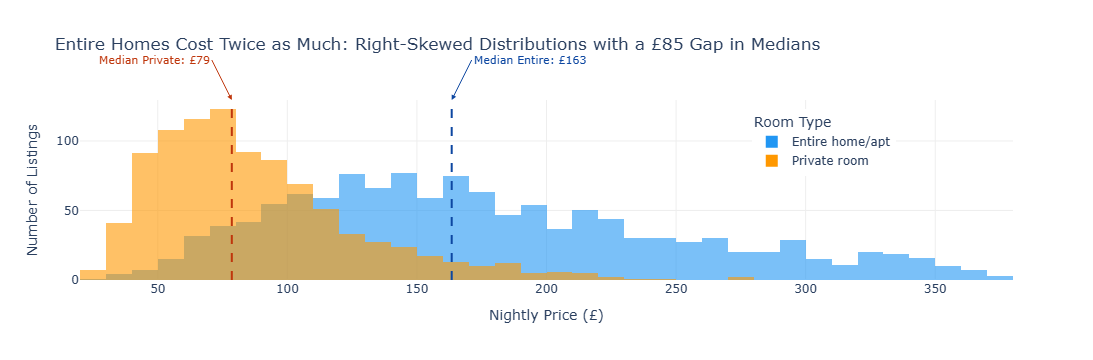

In [8]:
# Task 1 — Histogram: price by room type (overlapping distributions)
import pandas as pd
import plotly.express as px
import numpy as np

df = pd.read_csv('../data/airbnb_london.csv')
p95 = df['price'].quantile(0.95)
df_cap = df[df['price'] <= p95]

df_t1 = df_cap[df_cap['room_type'].isin(['Entire home/apt', 'Private room'])]

# Median per room type
medians = df_t1.groupby('room_type')['price'].median()
med_entire  = medians['Entire home/apt']   # £163
med_private = medians['Private room']      # £79

# Colour carries meaning: blue = full property (higher), orange = partial (lower)
color_map = {
    'Entire home/apt': '#2196F3',
    'Private room':    '#FF9800'
}

fig = px.histogram(
    df_t1,
    x='price',
    color='room_type',
    barmode='overlay',
    opacity=0.6,
    nbins=50,
    color_discrete_map=color_map,
    labels={'price': 'Nightly Price (£)', 'room_type': 'Room Type'},
    title=(
        'Entire Homes Cost Twice as Much: Right-Skewed Distributions with a £85 Gap in Medians<br>'
    )
)

# Median vertical lines — darker shades of each colour
for rt, med, lc, anchor in [
    ('Entire home/apt', med_entire,  '#0D47A1', 'left'),
    ('Private room',    med_private, '#BF360C', 'right'),
]:
    fig.add_vline(x=med, line_dash='dash', line_color=lc, line_width=2)
    fig.add_annotation(
        x=med, y=1, yref='paper',
        text=f"Median {rt.split()[0]}: £{med:.0f}",
        showarrow=True, arrowhead=2, arrowcolor=lc,
        font=dict(color=lc, size=11),
        xanchor=anchor,
        ax=20 if anchor == 'left' else -20, ay=-40,
    )

fig.update_layout(
    xaxis_title='Nightly Price (£)',
    yaxis_title='Number of Listings',
    legend_title='Room Type',
    legend=dict(x=0.72, y=0.95),
    plot_bgcolor='white', paper_bgcolor='white',
)
fig.update_xaxes(showgrid=True, gridcolor='#eeeeee')
fig.update_yaxes(showgrid=True, gridcolor='#eeeeee')
fig.show()



## Task 2 — Box plot: listing activity by borough

**What to build:** A **horizontal box plot** comparing listing activity (reviews per month) across London boroughs — reviews per month is a proxy for how frequently a listing is booked.

**Requirements:**
- Horizontal orientation (borough names are long)
- Sorted by median reviews per month (most active at top)
- Highlight the **two most active** boroughs in a different colour
- Outliers shown as individual points
- Insight title naming the two busiest boroughs

> 💡 Some listings have zero reviews — these are new or inactive listings. Filter them out with before plotting

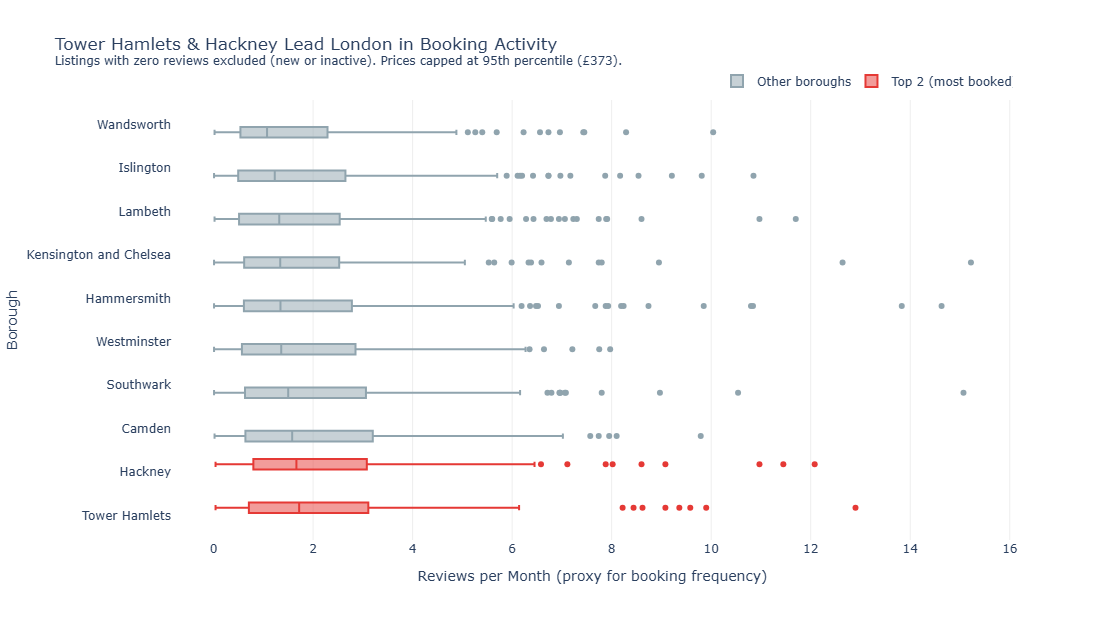

In [4]:
# Task 2 — Box plot: listing activity by borough
import pandas as pd
import plotly.express as px

df = pd.read_csv('../data/airbnb_london.csv')
p95 = df['price'].quantile(0.95)
df_cap = df[df['price'] <= p95]

# Drop zero-review listings (new / inactive)
df_t2 = df_cap[df_cap['reviews_per_month'] > 0].copy()

# Sort boroughs by median reviews/month; ascending so top borough appears at top of chart
order = (
    df_t2.groupby('neighbourhood')['reviews_per_month']
    .median()
    .sort_values(ascending=True)
    .index.tolist()
)

# Two most active boroughs highlighted (Tower Hamlets median 1.72, Hackney 1.67)
top2 = ['Tower Hamlets', 'Hackney']
df_t2['highlight'] = df_t2['neighbourhood'].apply(
    lambda b: 'Top 2 (most booked)' if b in top2 else 'Other boroughs'
)

color_map = {
    'Top 2 (most booked)': '#E53935',   # red = standout
    'Other boroughs':       '#90A4AE'    # grey = background
}

fig = px.box(
    df_t2,
    x='reviews_per_month',
    y='neighbourhood',
    color='highlight',
    color_discrete_map=color_map,
    orientation='h',
    category_orders={'neighbourhood': order},
    points='outliers',
    labels={
        'reviews_per_month': 'Reviews per Month (proxy for booking frequency)',
        'neighbourhood': 'Borough',
        'highlight': ''
    },
    title=(
        'Tower Hamlets & Hackney Lead London in Booking Activity<br>'
        '<sup>Listings with zero reviews excluded (new or inactive). '
        'Prices capped at 95th percentile (£373).</sup>'
    )
)

fig.update_layout(
    plot_bgcolor='white', paper_bgcolor='white',
    legend=dict(orientation='h', yanchor='bottom', y=1.01, xanchor='right', x=1),
    height=620,
    margin=dict(l=130),
)
fig.update_xaxes(showgrid=True, gridcolor='#eeeeee')
fig.update_yaxes(showgrid=False)
fig.show()